In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp

## Paired observations

The company made two major changes to its coding challenge platform. 

- In the first release, a new code-checking method was introduced. 

- In the second, solution feedback was added and the platform design was changed. 

30 users were randomly selected. Before the releases and after each release, they were asked to complete the same three-question survey.

- First question Q1: "Are you satisfied with the quality of the code checking?"

- Second question Q2: "Is the code checked quickly enough?"

- Third question Q3: "Rate the platform design on a scale from 1 to 10."

In [2]:
before = pd.read_csv("sml_before.csv")
first = pd.read_csv("sml_first_update.csv")
second = pd.read_csv("sml_second_update.csv")

In [3]:
before.columns

Index(['Client', 'Q1', 'Q2', 'Q3'], dtype='str')

In [4]:
before.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Client  30 non-null     str  
 1   Q1      30 non-null     str  
 2   Q2      30 non-null     str  
 3   Q3      30 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.1 KB


In [5]:
question_names = ['Q1', 'Q2', 'Q3']

for col in question_names:
    print(f'Uniqune values for the {col} column: {before[col].unique()}')

Uniqune values for the Q1 column: <StringArray>
[         'Недоволен(а)', 'Очень удовлетворен(а)',         'Нейтрален(на)',
    'Очень недоволен(а)',       'Удовлетворен(а)']
Length: 5, dtype: str
Uniqune values for the Q2 column: <StringArray>
['Довольно быстро', 'Медленно', 'Очень медленно', 'Очень быстро', 'Средне']
Length: 5, dtype: str
Uniqune values for the Q3 column: [ 4  6  9  1  5  8  7 10  3]


In [6]:
questions = {}
questions['Q1'] = ['Очень недоволен(а)', 'Недоволен(а)', 'Нейтрален(на)', 'Удовлетворен(а)', 'Очень удовлетворен(а)']
questions['Q2'] = ['Очень медленно', 'Медленно', 'Средне', 'Довольно быстро', 'Очень быстро']
questions['Q3'] = range(1, 11)

In [7]:
for q in question_names:
    print(f'For question {q} possible values are the same as before: {all(first[q].isin(questions[q]))}')

For question Q1 possible values are the same as before: True
For question Q2 possible values are the same as before: True
For question Q3 possible values are the same as before: True


In [8]:
for q in question_names:
    print(f'For question {q} possible values are the same as before: {all(second[q].isin(questions[q]))}')

For question Q1 possible values are the same as before: True
For question Q2 possible values are the same as before: True
For question Q3 possible values are the same as before: True


Map the literal answers for questions 1 and 2 to numeric labels. Skip the question with a numeric answer type.

In [9]:
tests = [before, first, second]

for test  in tests:
    for col in question_names:
        if not pd.api.types.is_numeric_dtype(test[col]):
            test[col + '_num'] = test[col].map({v: i for v, i in zip(questions[col], range(1, len(questions[col])+1))})

In [10]:
numeric_cols = ['Q1_num', 'Q2_num', 'Q3']

In [11]:
test.head()

,Client,Q1,Q2,Q3,Q1_num,Q2_num
0,User_1,Нейтрален(на),Очень быстро,9,3,5
1,User_2,Очень удовлетворен(а),Средне,8,5,3
2,User_3,Нейтрален(на),Довольно быстро,7,3,4
3,User_4,Очень недоволен(а),Средне,8,1,3
4,User_5,Нейтрален(на),Очень быстро,8,3,5


### First release. 

In [119]:
def plot_release_results(before, after, release):
    fig, axes = plt.subplots(1, len(question_names), figsize=(17, 5))

    x_lims = {q: v for q, v in zip(numeric_cols, [(-4.5, 4.5), (-4.5, 4.5), (-9.5, 9.5)])}

    for ax, q in zip(axes, numeric_cols):
        ax.hist(after[q] - before[q], bins=9)
        ax.set_ylim(0, 10)
        ax.set_title(f'Release {release}, question {q}')
        ax.set_xlim(*x_lims[q])

    plt.tight_layout()
    plt.show()

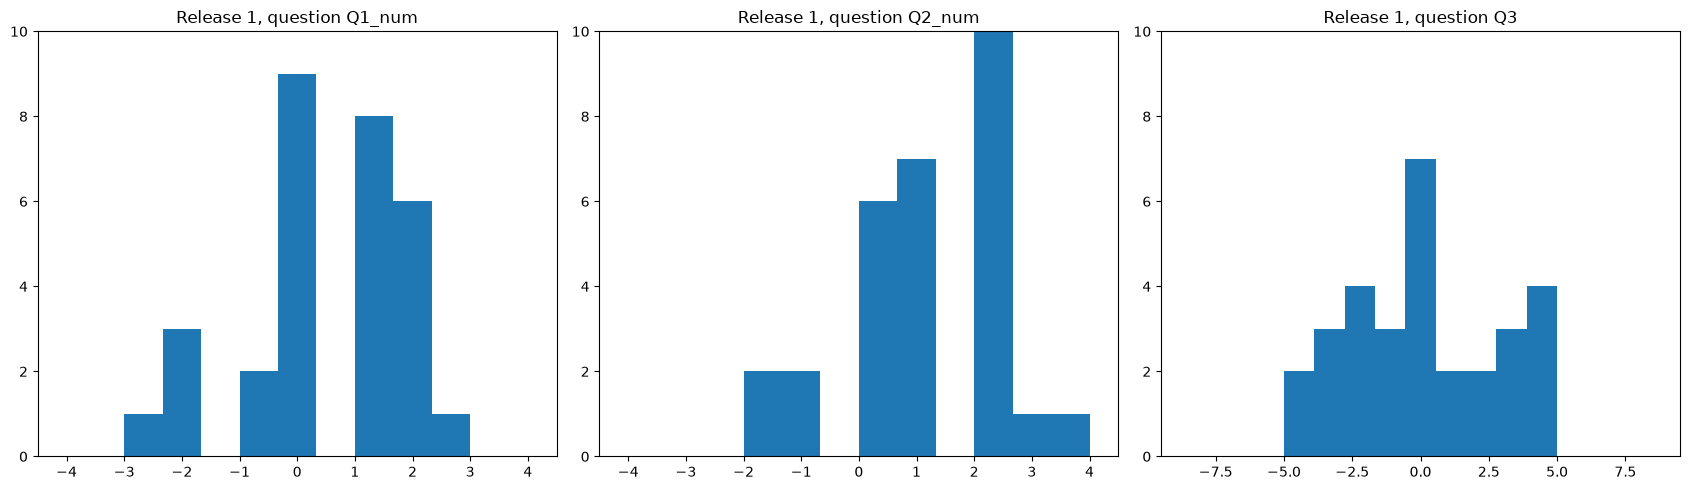

In [120]:
plot_release_results(before=before, after=first, release=1)

The plot above shows the differences between users’ answers before and after the first release for all three questions. 

The first release affected only the code-checking part of the system; there were no changes to the platform design. 

Despite this, many users changed their answers to the third question. 

One possible explanation is that when users are satisfied with changes to one part of the platform (such as code checking), they may become more satisfied with the platform as a whole. 

Let’s check the correlation between the before-and-after differences for the three questions.

In [77]:
(first[numeric_cols] - before[numeric_cols]).corr()

,Q1_num,Q2_num,Q3
Q1_num,1.000000,0.017368,0.396626
Q2_num,0.017368,1.000000,-0.047640
Q3,0.396626,-0.047640,1.000000


### First question analysis

First, check the data for normality. We have already looked at the histogram, so let's plot a Q-Q plot.

In [102]:
def pprint(result):
    print(f'{type(result).__name__}')
    for field, value in zip(result._fields, result):
            print(f'\t{field}: {value}')



def normality_check(before, after, release, question):
    diff = after[question] - before[question]
    stats.probplot(diff, plot=plt)
    plt.title(f'Q-Q plot for the {release} release, question {question}')
    plt.show()

    shapiro_result = stats.shapiro(diff)
    pprint(shapiro_result)
    

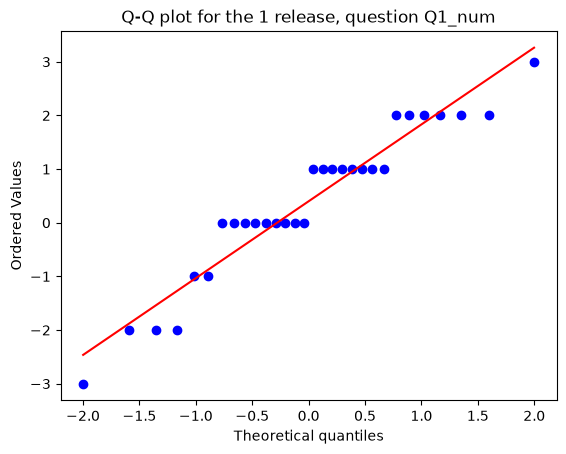

ShapiroResult
	statistic: 0.9305259439718945
	pvalue: 0.05070880134621992


In [116]:
release = 1
q = 'Q1_num'

normality_check(before, first, release=release, question=q)

According to the plots above and the result of the Shapiro normality test, we don't have strong statistical evidence of non-normality. 

We test the null hypothesis (for the first question) on the equality of the mean difference to zero with paired ttest. The alternative is two-sided.

In [94]:
result = stats.ttest_rel(first[q], before[q])
pprint(result)
pprint(result.confidence_interval(confidence_level=0.95))

TtestResult
	statistic: 1.533411670541004
	pvalue: 0.13601277395705214
ConfidenceInterval
	low: -0.1335109107161354
	high: 0.9335109107161355


With an observed t-statistic of 1.53 and a p-value of 0.1360, there is insufficient evidence to reject the null hypothesis.

Let's calculate the statistical power of a two-sided test at $\alpha=0.05$.

In [95]:
def power(diff, alternative, alpha):
    se = diff.std() / np.sqrt(diff.size)
    
    critical_value = stats.norm.ppf(1 - alpha/2)

    noncentral_norm = stats.norm(loc=alternative, scale=se)

    beta = noncentral_norm.cdf(critical_value * se) - noncentral_norm.cdf(-critical_value * se)

    return 1 - beta

In [97]:
diff = (first[q] - before[q])
alpha = 0.05
alternatives = [1, 0.5, 0]

print(f'Statistical power of a two-sided test at {alpha} significance level, assuming the true population mean difference')
for alternative in alternatives:
    print(f'\t {alternative} \t{power(diff, alternative, alpha)}')

Statistical power of a two-sided test at 0.05 significance level, assuming the true population mean difference
	 1 	0.9695048137266371
	 0.5 	0.4828242283117684
	 0 	0.050000000000000044


In [117]:
result = stats.wilcoxon(first[q], before[q])
pprint(result)

WilcoxonResult
	statistic: 76.5
	pvalue: 0.16580656019401352


### For the second question

let's see if the normality checks also gives positive result.

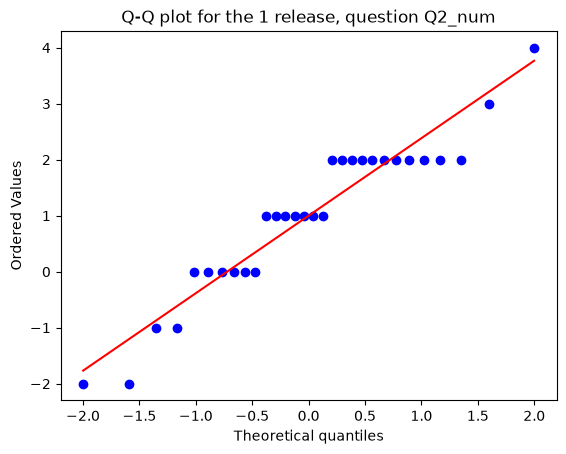

ShapiroResult
	statistic: 0.9221957236441111
	pvalue: 0.030591284483976428


In [104]:
q = 'Q2_num'

normality_check(before, first, release=release, question=q)

The Shapiro–Wilk test statistic is 0.92 and the p-value is 0.03. We reject the null hypothesis of normality and conclude that there is statistically significant evidence under the significance level 0.05 that the data are not normally distributed.

Since the second question’s differences are not normally distributed, the appropriate nonparametric test is the Wilcoxon signed-rank test.

Since the research question is whether the platform change improved users’ responses, we will use a one-sided Wilcoxon signed-rank test with the alternative hypothesis that the responses increased after the change.

In [113]:
result = stats.wilcoxon(first[q], before[q], alternative='greater')
pprint(result)

WilcoxonResult
	statistic: 258.0
	pvalue: 0.0007757975438773624


The right-sided Wilcoxon signed-rank test produced a p-value of 0.0007758. 

Since the p-value is below the 5% significance level, we reject the null hypothesis that users’ responses did not systematically increase after the release. 

There is statistically significant evidence that users’ assessments improved after the release.

### For the third question

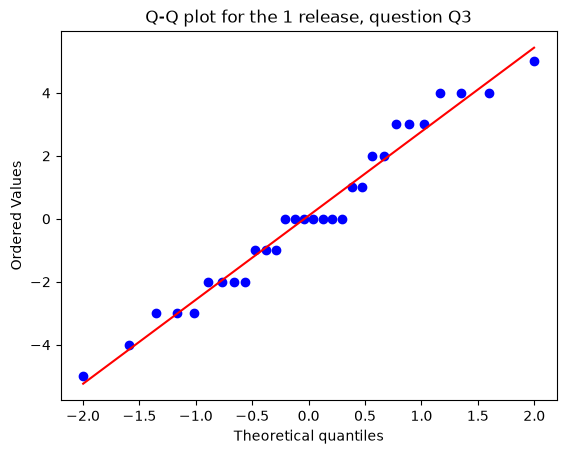

ShapiroResult
	statistic: 0.9660667135523967
	pvalue: 0.43786484722395214


In [114]:
q = 'Q3'
normality_check(before=before, after=first, release=1, question=q)

In [118]:
result = stats.wilcoxon(first[q], before[q])
pprint(result)

WilcoxonResult
	statistic: 76.5
	pvalue: 0.16580656019401352


### Second release

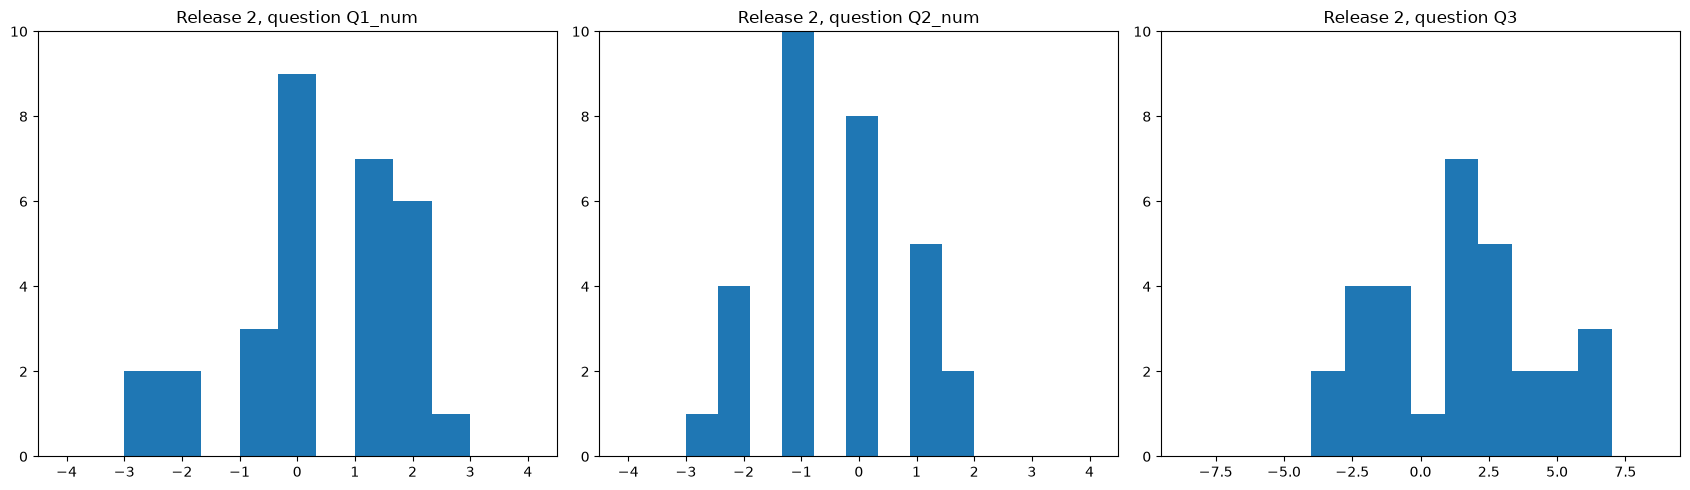

In [121]:
plot_release_results(before=first, after=second, release=2)

In [124]:
for q in numeric_cols:
    print(f'\nRun Wilcoxon test for question {q}')
    result = stats.wilcoxon(second[q], first[q])
    pprint(result)



Run Wilcoxon test for question Q1_num
WilcoxonResult
	statistic: 85.5
	pvalue: 0.28767388504619185

Run Wilcoxon test for question Q2_num
WilcoxonResult
	statistic: 77.0
	pvalue: 0.09412993320593757

Run Wilcoxon test for question Q3
WilcoxonResult
	statistic: 115.5
	pvalue: 0.026399854564250255


Если мы имеем парные выборки (измеренный признак у одних и тех же объектов при разных условиях), тогда мы не можем применять критерии для независимых выборок.

Сначала проверяем нормальность данных. Если данные взяты из нормального распределения, тогда можно применять параметрические критерии:

Критерий Стьюдента для двух парных выборок - scipy.stats.ttest_rel(a, b, alternative='two-sided')

Однофакторный дисперсионный анализ для трех и более парных выборок

Если же данные не нормальные и не удалось преобразовать их к нормальным, тогда используем непараметрические критерии:

Для двух выборок:

W-критерий Вилкоксона  - scipy.stats.wilcoxon(x, y=None, alternative='two-sided')
- данных в выборке меньше 50
- большой разброс разностей

G-критерий знаков
- порядковые переменные
- данных в выборке от 5 до 300
- маленький разброс разностей

Для трех и более выборок:

Критерий Фридмана - scipy.stats.friedmanchisquare(*samples)
- больше 3 выборок
- объем выборок больше 2